# PSF Analysis for Roman Space Telescope Grism

This notebook analyzes the Point Spread Function (PSF) characteristics of the Roman Space Telescope grism at various detector positions and wavelengths.

**Part 1: Single Detector Deep Dive (WFI02)**
- PSF images at center and corner positions
- Encircled energy curves
- FWHM measurements
- GRISM0 vs GRISM1 comparison

**Part 2: All Detectors Survey (WFI01-WFI18)**
- PSFs at detector centers
- Cross-detector variation analysis

## Setup & Configuration

In [1]:
# Imports
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

import stpsf.roman

from roman_disperser.psf_utils import sca_to_stpsf_position

# Use larger fonts for better readability
plt.rcParams['font.size'] = 11

In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Wavelengths to analyze (microns)
WAVELENGTHS_UM = [1.0, 1.5, 1.93]

# Convert to meters for STPSF
WAVELENGTHS_M = [w * 1e-6 for w in WAVELENGTHS_UM]

# PSF calculation parameters
OVERSAMPLE = 4      # Oversampling factor
FOV_ARCSEC = 7.0    # Field of view in arcseconds

# Spectral orders (STPSF filter names)
ORDERS = ['GRISM0', 'GRISM1']

# PSF extension to use
PSF_EXTENSION = 'OVERDIST'  # Oversampled + detector effects

# Pixel scale (arcsec/pixel, Roman WFI native)
PIXEL_SCALE = 0.11

# Positions on detector (SCA coordinates, FITS 1-indexed)
POSITIONS = {
    'center': (2044, 2044),
    'corner_ll': (1, 1),
    'corner_lr': (4088, 1),
    'corner_ul': (1, 4088),
    'corner_ur': (4088, 4088),
}

# Detector for Part 1
DETECTOR_PART1 = 'WFI02'

print("Configuration:")
print(f"  Wavelengths: {WAVELENGTHS_UM} μm")
print(f"  Oversampling: {OVERSAMPLE}×")
print(f"  FOV: {FOV_ARCSEC} arcsec")
print(f"  Orders: {ORDERS}")
print(f"  PSF Extension: {PSF_EXTENSION}")
print(f"  Detector: {DETECTOR_PART1}")
print(f"  Positions: {list(POSITIONS.keys())}")

Configuration:
  Wavelengths: [1.0, 1.5, 1.93] μm
  Oversampling: 4×
  FOV: 7.0 arcsec
  Orders: ['GRISM0', 'GRISM1']
  PSF Extension: OVERDIST
  Detector: WFI02
  Positions: ['center', 'corner_ll', 'corner_lr', 'corner_ul', 'corner_ur']


## Helper Functions

In [3]:
def compute_encircled_energy(psf_array, pixel_scale_arcsec):
    """
    Compute encircled energy as a function of radius.
    
    Parameters
    ----------
    psf_array : ndarray
        2D PSF image array
    pixel_scale_arcsec : float
        Pixel scale in arcseconds per pixel
    
    Returns
    -------
    radii : ndarray
        Radii in arcseconds
    ee : ndarray
        Encircled energy fraction (0 to 1)
    """
    # Get PSF center
    ny, nx = psf_array.shape
    cy, cx = (ny - 1) / 2.0, (nx - 1) / 2.0
    
    # Compute radius for each pixel
    y, x = np.mgrid[0:ny, 0:nx]
    r_pix = np.sqrt((x - cx)**2 + (y - cy)**2)
    r_arcsec = r_pix * pixel_scale_arcsec
    
    # Flatten and sort by radius
    r_flat = r_arcsec.ravel()
    flux_flat = psf_array.ravel()
    
    sort_idx = np.argsort(r_flat)
    r_sorted = r_flat[sort_idx]
    flux_sorted = flux_flat[sort_idx]
    
    # Compute cumulative sum (encircled energy)
    ee_cumsum = np.cumsum(flux_sorted)
    ee_total = ee_cumsum[-1]
    ee_frac = ee_cumsum / ee_total
    
    return r_sorted, ee_frac


def find_ee_radius(radii, ee, target_ee):
    """
    Find the radius that encloses a given fraction of energy.
    
    Parameters
    ----------
    radii : ndarray
        Radii in arcseconds
    ee : ndarray
        Encircled energy fraction
    target_ee : float
        Target encircled energy fraction (e.g., 0.5 for EE50)
    
    Returns
    -------
    radius : float
        Radius in arcseconds that encloses target_ee fraction
    """
    idx = np.searchsorted(ee, target_ee)
    if idx >= len(radii):
        return radii[-1]
    return radii[idx]


def estimate_fwhm_from_ee50(ee50_radius):
    """
    Estimate FWHM from EE50 radius.

    For a Gaussian PSF: EE50 ≈ 0.674σ and FWHM = 2.355σ, so FWHM ≈ 3.5 × EE50.
    For real PSFs with extended wings, the ratio is typically closer to 2.0-2.5.
    We use 2.0 as a conservative estimate (diameter = 2 × EE50 radius).

    Parameters
    ----------
    ee50_radius : float
        Radius enclosing 50% of the energy (arcsec)

    Returns
    -------
    fwhm_estimate : float
        Estimated FWHM in arcseconds (= 2 × EE50 radius)
    """
    return 2.0 * ee50_radius


def calculate_psf(wfi, wavelength_m, fov_arcsec, oversample, extension='OVERDIST'):
    """
    Calculate a single PSF.
    
    Parameters
    ----------
    wfi : stpsf.roman.WFI
        STPSF WFI instrument object (pre-configured with filter, detector, position)
    wavelength_m : float
        Wavelength in meters
    fov_arcsec : float
        Field of view in arcseconds
    oversample : int
        Oversampling factor
    extension : str
        FITS extension to use ('OVERDIST', 'OVERSAMP', etc.)
    
    Returns
    -------
    psf_array : ndarray
        PSF image array
    """
    psf_hdu = wfi.calc_psf(
        monochromatic=wavelength_m,
        fov_arcsec=fov_arcsec,
        oversample=oversample
    )
    return psf_hdu[extension].data


print("Helper functions defined.")

Helper functions defined.


---

# Part 1: Single Detector Deep Dive (WFI02)

## PSF Calculation

Calculate PSFs for all combinations of:
- 2 orders (GRISM0, GRISM1)
- 5 positions (center + 4 corners)
- 3 wavelengths (1.0, 1.5, 1.93 μm)

In [4]:
# Initialize STPSF WFI instrument
wfi = stpsf.roman.WFI()
wfi.detector = DETECTOR_PART1

# Storage for PSFs
# Structure: psfs[order][position_name][wavelength_um] = psf_array
psfs = {order: {} for order in ORDERS}

# Pixel scale for oversampled PSF
psf_pixel_scale = PIXEL_SCALE / OVERSAMPLE

# Total PSFs to calculate
n_total = len(ORDERS) * len(POSITIONS) * len(WAVELENGTHS_UM)
n_done = 0

print(f"Calculating {n_total} PSFs for {DETECTOR_PART1}...")
print(f"  Orders: {ORDERS}")
print(f"  Positions: {list(POSITIONS.keys())}")
print(f"  Wavelengths: {WAVELENGTHS_UM} μm")
print()

t_start = time.time()

for order in ORDERS:
    wfi.filter = order
    
    for pos_name, (xsca, ysca) in POSITIONS.items():
        # Convert SCA to STPSF coordinates
        x_stpsf, y_stpsf = sca_to_stpsf_position(float(xsca), float(ysca))
        wfi.detector_position = (float(x_stpsf), float(y_stpsf))
        
        psfs[order][pos_name] = {}
        
        for wl_um, wl_m in zip(WAVELENGTHS_UM, WAVELENGTHS_M):
            t0 = time.time()
            psf_array = calculate_psf(
                wfi, wl_m, FOV_ARCSEC, OVERSAMPLE, PSF_EXTENSION
            )
            elapsed = time.time() - t0
            
            psfs[order][pos_name][wl_um] = psf_array
            
            n_done += 1
            print(f"  [{n_done}/{n_total}] {order}, {pos_name}, {wl_um} μm: "
                  f"{elapsed:.2f}s, shape={psf_array.shape}")

t_total = time.time() - t_start
print(f"\nCompleted in {t_total:.1f} seconds ({t_total/n_total:.2f}s per PSF)")

Calculating 30 PSFs for WFI02...
  Orders: ['GRISM0', 'GRISM1']
  Positions: ['center', 'corner_ll', 'corner_lr', 'corner_ul', 'corner_ur']
  Wavelengths: [1.0, 1.5, 1.93] μm

  [1/30] GRISM0, center, 1.0 μm: 3.32s, shape=(260, 260)
  [2/30] GRISM0, center, 1.5 μm: 0.39s, shape=(260, 260)


Attempted to get aberrations at field point (4, 4) which is outside the range of the reference data; approximating to nearest interpolated point (39.34463063570345, 3.9913179487507477)


  [3/30] GRISM0, center, 1.93 μm: 0.36s, shape=(260, 260)


Attempted to get aberrations at field point (4, 4) which is outside the range of the reference data; approximating to nearest interpolated point (39.34463063570345, 3.9913179487507477)


  [4/30] GRISM0, corner_ll, 1.0 μm: 0.38s, shape=(260, 260)


...

  [27/30] GRISM1, corner_ul, 1.93 μm: 0.36s, shape=(260, 260)


Attempted to get aberrations at field point (4091, 4091) which is outside the range of the reference data; approximating to nearest input grid point


  [28/30] GRISM1, corner_ur, 1.0 μm: 0.36s, shape=(260, 260)


Attempted to get aberrations at field point (4091, 4091) which is outside the range of the reference data; approximating to nearest input grid point


  [29/30] GRISM1, corner_ur, 1.5 μm: 0.37s, shape=(260, 260)
  [30/30] GRISM1, corner_ur, 1.93 μm: 0.37s, shape=(260, 260)

Completed in 14.2 seconds (0.47s per PSF)


## PSF Image Gallery

Display PSFs on a log scale for each position and wavelength.

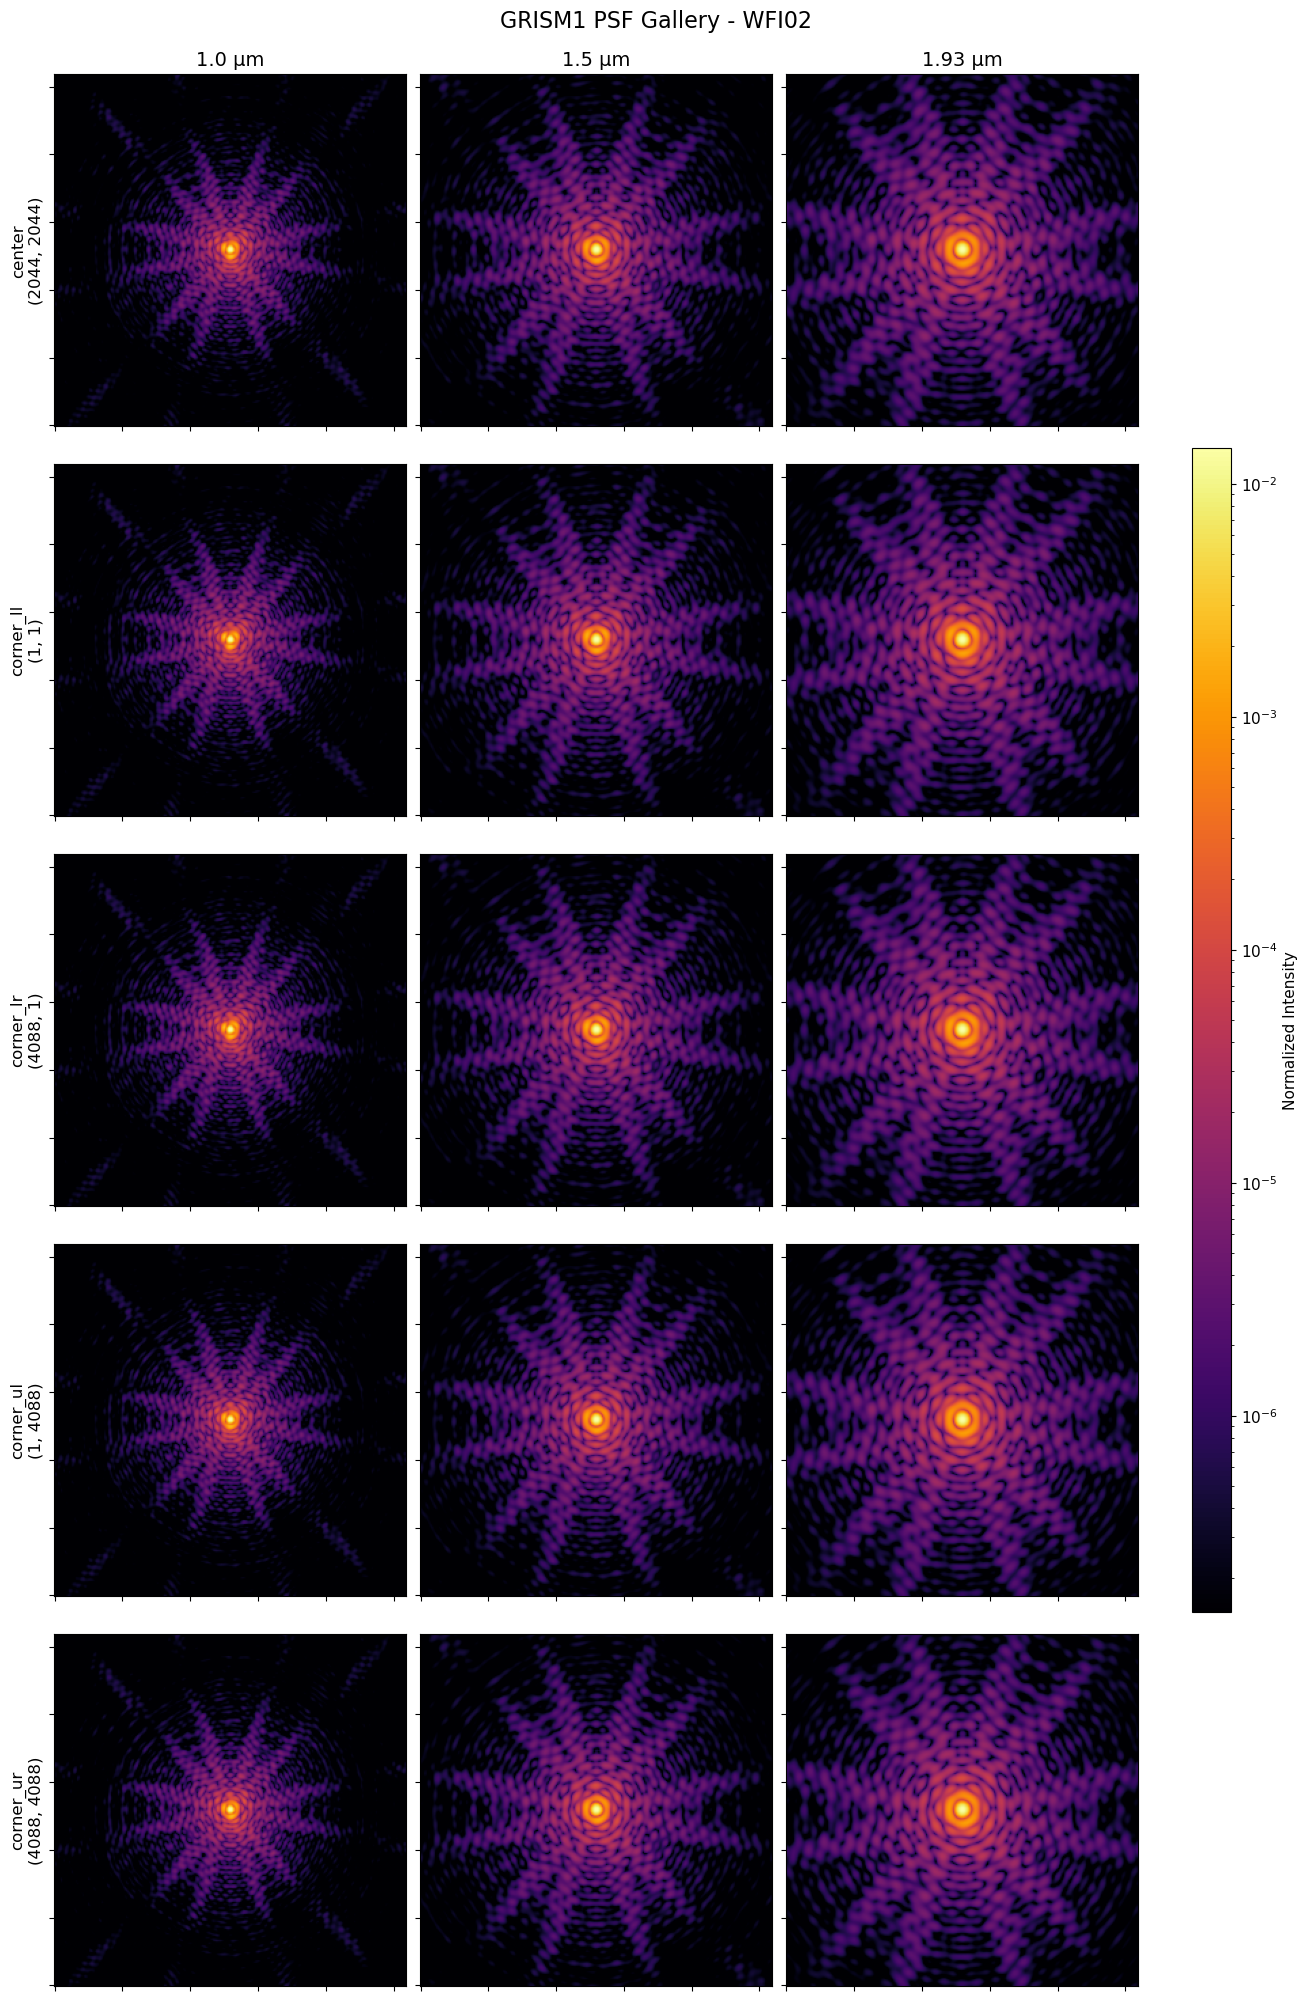

In [5]:
# PSF Gallery for GRISM1 (primary science order)
order = 'GRISM1'

n_positions = len(POSITIONS)
n_wavelengths = len(WAVELENGTHS_UM)

fig, axes = plt.subplots(
    n_positions, n_wavelengths,
    figsize=(4 * n_wavelengths + 1, 4 * n_positions),
    constrained_layout=True
)

for i, (pos_name, (xsca, ysca)) in enumerate(POSITIONS.items()):
    for j, wl_um in enumerate(WAVELENGTHS_UM):
        ax = axes[i, j]
        psf_array = psfs[order][pos_name][wl_um]
        
        # Log scale with 5 orders of magnitude dynamic range
        vmax = psf_array.max()
        vmin = vmax * 1e-5
        
        im = ax.imshow(
            psf_array,
            origin='lower',
            cmap='inferno',
            norm=LogNorm(vmin=vmin, vmax=vmax)
        )
        
        # Labels
        if i == 0:
            ax.set_title(f'{wl_um} μm', fontsize=14)
        if j == 0:
            ax.set_ylabel(f'{pos_name}\n({xsca}, {ysca})', fontsize=12)
        
        ax.tick_params(labelbottom=False, labelleft=False)

# Add colorbar on the right
cbar = fig.colorbar(im, ax=axes, location='right', shrink=0.6, aspect=30)
cbar.set_label('Normalized Intensity')

fig.suptitle(f'{order} PSF Gallery - {DETECTOR_PART1}', fontsize=16)
plt.show()

## Encircled Energy Curves

Plot encircled energy as a function of radius, with 50%, 90%, and 95% levels marked.

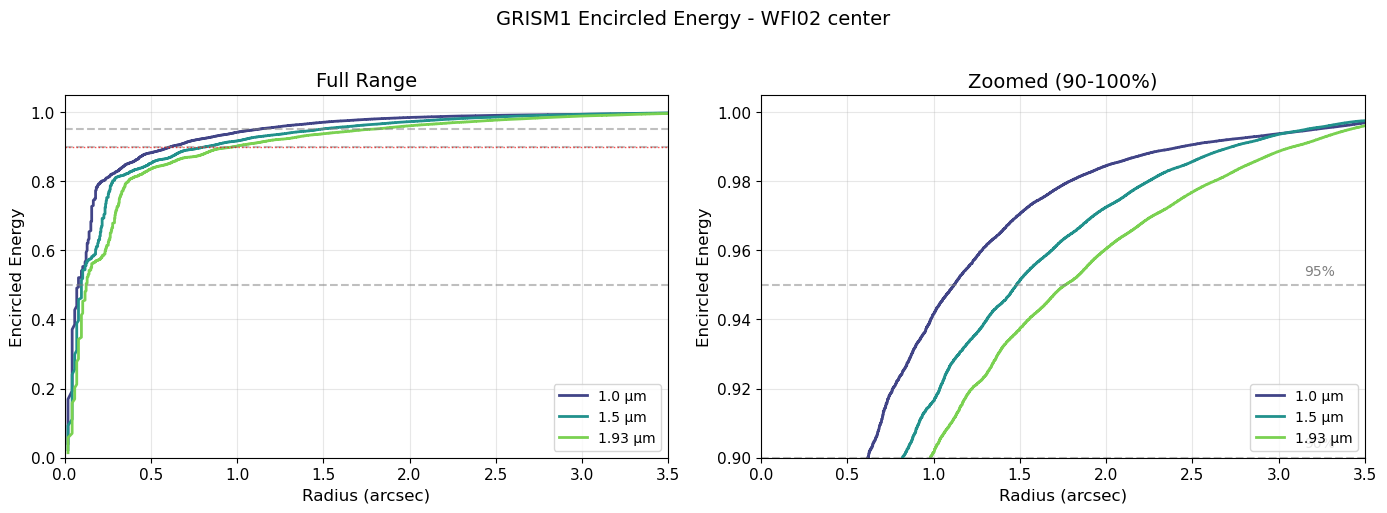

In [6]:
# Encircled Energy for GRISM1 at center position
order = 'GRISM1'
pos_name = 'center'

# Max radius is FOV/2
max_radius = FOV_ARCSEC / 2.0

fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(WAVELENGTHS_UM)))

# EE levels to mark
ee_levels = [0.50, 0.90, 0.95]

for wl_um, color in zip(WAVELENGTHS_UM, colors):
    psf_array = psfs[order][pos_name][wl_um]
    radii, ee = compute_encircled_energy(psf_array, psf_pixel_scale)
    
    ax_full.plot(radii, ee, '-', color=color, linewidth=2, label=f'{wl_um} μm')
    ax_zoom.plot(radii, ee, '-', color=color, linewidth=2, label=f'{wl_um} μm')

# Full range plot (left)
for level in ee_levels:
    ax_full.axhline(level, color='gray', linestyle='--', alpha=0.5)
ax_full.axhline(0.90, color='red', linestyle=':', alpha=0.7, linewidth=1)
ax_full.set_xlabel('Radius (arcsec)', fontsize=12)
ax_full.set_ylabel('Encircled Energy', fontsize=12)
ax_full.set_title('Full Range', fontsize=14)
ax_full.set_xlim(0, max_radius)
ax_full.set_ylim(0, 1.05)
ax_full.legend(loc='lower right', fontsize=10)
ax_full.grid(alpha=0.3)

# Zoomed plot (right)
for level in [0.90, 0.95]:
    ax_zoom.axhline(level, color='gray', linestyle='--', alpha=0.5)
    ax_zoom.text(max_radius * 0.95, level + 0.002, f'{int(level*100)}%',
                 ha='right', va='bottom', color='gray', fontsize=10)
ax_zoom.set_xlabel('Radius (arcsec)', fontsize=12)
ax_zoom.set_ylabel('Encircled Energy', fontsize=12)
ax_zoom.set_title('Zoomed (90-100%)', fontsize=14)
ax_zoom.set_xlim(0, max_radius)
ax_zoom.set_ylim(0.90, 1.005)
ax_zoom.legend(loc='lower right', fontsize=10)
ax_zoom.grid(alpha=0.3)

fig.suptitle(f'{order} Encircled Energy - {DETECTOR_PART1} {pos_name}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

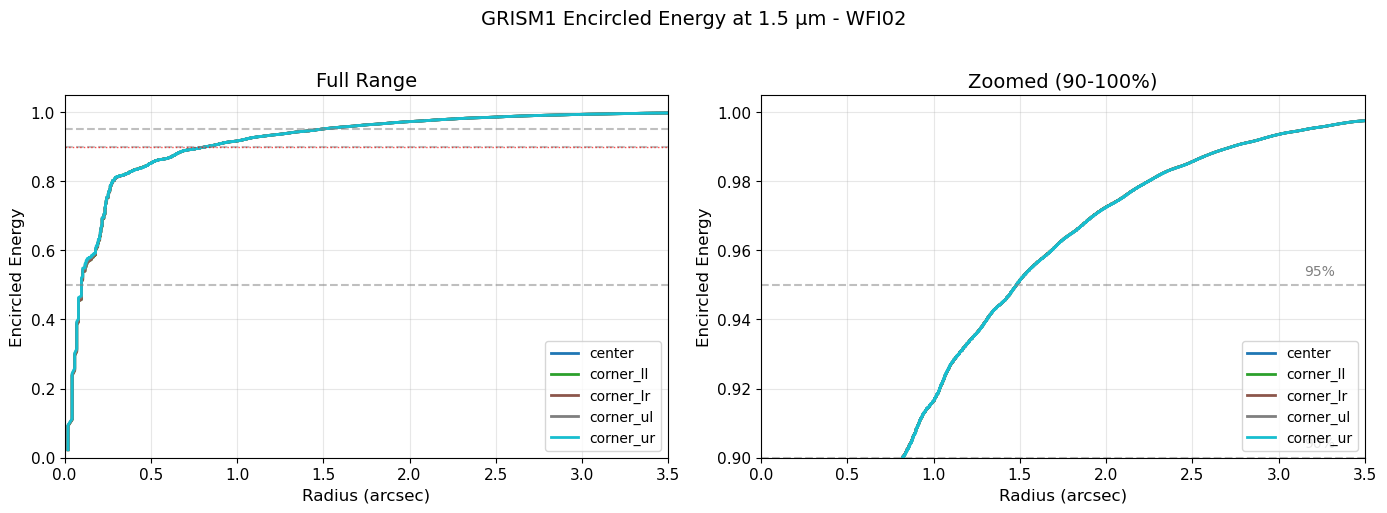

In [7]:
# Encircled Energy comparison across positions (at 1.5 μm)
order = 'GRISM1'
wl_um = 1.5

# Max radius is FOV/2
max_radius = FOV_ARCSEC / 2.0

fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.tab10(np.linspace(0, 1, len(POSITIONS)))

for (pos_name, _), color in zip(POSITIONS.items(), colors):
    psf_array = psfs[order][pos_name][wl_um]
    radii, ee = compute_encircled_energy(psf_array, psf_pixel_scale)
    
    ax_full.plot(radii, ee, '-', color=color, linewidth=2, label=pos_name)
    ax_zoom.plot(radii, ee, '-', color=color, linewidth=2, label=pos_name)

# Full range plot (left)
for level in ee_levels:
    ax_full.axhline(level, color='gray', linestyle='--', alpha=0.5)
ax_full.axhline(0.90, color='red', linestyle=':', alpha=0.7, linewidth=1)
ax_full.set_xlabel('Radius (arcsec)', fontsize=12)
ax_full.set_ylabel('Encircled Energy', fontsize=12)
ax_full.set_title('Full Range', fontsize=14)
ax_full.set_xlim(0, max_radius)
ax_full.set_ylim(0, 1.05)
ax_full.legend(loc='lower right', fontsize=10)
ax_full.grid(alpha=0.3)

# Zoomed plot (right)
for level in [0.90, 0.95]:
    ax_zoom.axhline(level, color='gray', linestyle='--', alpha=0.5)
    ax_zoom.text(max_radius * 0.95, level + 0.002, f'{int(level*100)}%',
                 ha='right', va='bottom', color='gray', fontsize=10)
ax_zoom.set_xlabel('Radius (arcsec)', fontsize=12)
ax_zoom.set_ylabel('Encircled Energy', fontsize=12)
ax_zoom.set_title('Zoomed (90-100%)', fontsize=14)
ax_zoom.set_xlim(0, max_radius)
ax_zoom.set_ylim(0.90, 1.005)
ax_zoom.legend(loc='lower right', fontsize=10)
ax_zoom.grid(alpha=0.3)

fig.suptitle(f'{order} Encircled Energy at {wl_um} μm - {DETECTOR_PART1}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## EE Radius Table

Summary table of encircled energy radii (EE50, EE90, EE95) for all PSFs.

In [8]:
# Compute EE radii for GRISM1
order = 'GRISM1'

ee_data = []

for pos_name, (xsca, ysca) in POSITIONS.items():
    for wl_um in WAVELENGTHS_UM:
        psf_array = psfs[order][pos_name][wl_um]
        radii, ee = compute_encircled_energy(psf_array, psf_pixel_scale)
        
        ee50 = find_ee_radius(radii, ee, 0.50)
        ee90 = find_ee_radius(radii, ee, 0.90)
        ee95 = find_ee_radius(radii, ee, 0.95)
        
        ee_data.append({
            'Position': pos_name,
            'λ (μm)': wl_um,
            'EE50 (arcsec)': f'{ee50:.3f}',
            'EE90 (arcsec)': f'{ee90:.3f}',
            'EE95 (arcsec)': f'{ee95:.3f}',
        })

ee_df = pd.DataFrame(ee_data)
print(f"\n{order} Encircled Energy Radii - {DETECTOR_PART1}")
print("=" * 70)
ee_df


GRISM1 Encircled Energy Radii - WFI02


,Position,λ (μm),EE50 (arcsec),EE90 (arcsec),EE95 (arcsec)
0,center,1.00,0.080,0.618,1.118
1,center,1.50,0.097,0.820,1.479
2,center,1.93,0.125,0.981,1.763
3,corner_ll,1.00,0.080,0.621,1.116
4,corner_ll,1.50,0.097,0.820,1.479
5,corner_ll,1.93,0.125,0.981,1.764
6,corner_lr,1.00,0.080,0.620,1.116
7,corner_lr,1.50,0.097,0.820,1.479
8,corner_lr,1.93,0.125,0.979,1.766
9,corner_ul,1.00,0.080,0.618,1.118


## FWHM Estimates (from EE50)

FWHM is estimated as 2 × EE50 radius, which provides a robust size metric even for non-Gaussian PSFs with extended wings.

In [9]:
# Compute FWHM (estimated from EE50) for GRISM1
order = 'GRISM1'

fwhm_data = []

for pos_name, (xsca, ysca) in POSITIONS.items():
    for wl_um in WAVELENGTHS_UM:
        psf_array = psfs[order][pos_name][wl_um]
        radii, ee = compute_encircled_energy(psf_array, psf_pixel_scale)
        ee50 = find_ee_radius(radii, ee, 0.50)
        fwhm = estimate_fwhm_from_ee50(ee50)
        
        fwhm_data.append({
            'Position': pos_name,
            'λ (μm)': wl_um,
            'EE50 (arcsec)': f'{ee50:.3f}',
            'FWHM est (arcsec)': f'{fwhm:.3f}',
            'FWHM est (pixels)': f'{fwhm / PIXEL_SCALE:.2f}',
        })

fwhm_df = pd.DataFrame(fwhm_data)
print(f"\n{order} FWHM Estimates (from EE50) - {DETECTOR_PART1}")
print("Note: FWHM ≈ 2 × EE50 radius")
print("=" * 70)
fwhm_df


GRISM1 FWHM Estimates (from EE50) - WFI02
Note: FWHM ≈ 2 × EE50 radius


,Position,λ (μm),EE50 (arcsec),FWHM est (arcsec),FWHM est (pixels)
0,center,1.00,0.080,0.160,1.46
1,center,1.50,0.097,0.194,1.77
2,center,1.93,0.125,0.249,2.26
3,corner_ll,1.00,0.080,0.160,1.46
4,corner_ll,1.50,0.097,0.194,1.77
5,corner_ll,1.93,0.125,0.249,2.26
6,corner_lr,1.00,0.080,0.160,1.46
7,corner_lr,1.50,0.097,0.194,1.77
8,corner_lr,1.93,0.125,0.249,2.26
9,corner_ul,1.00,0.080,0.160,1.46


## GRISM0 vs GRISM1 Comparison

Side-by-side comparison of PSFs from both orders at detector center.

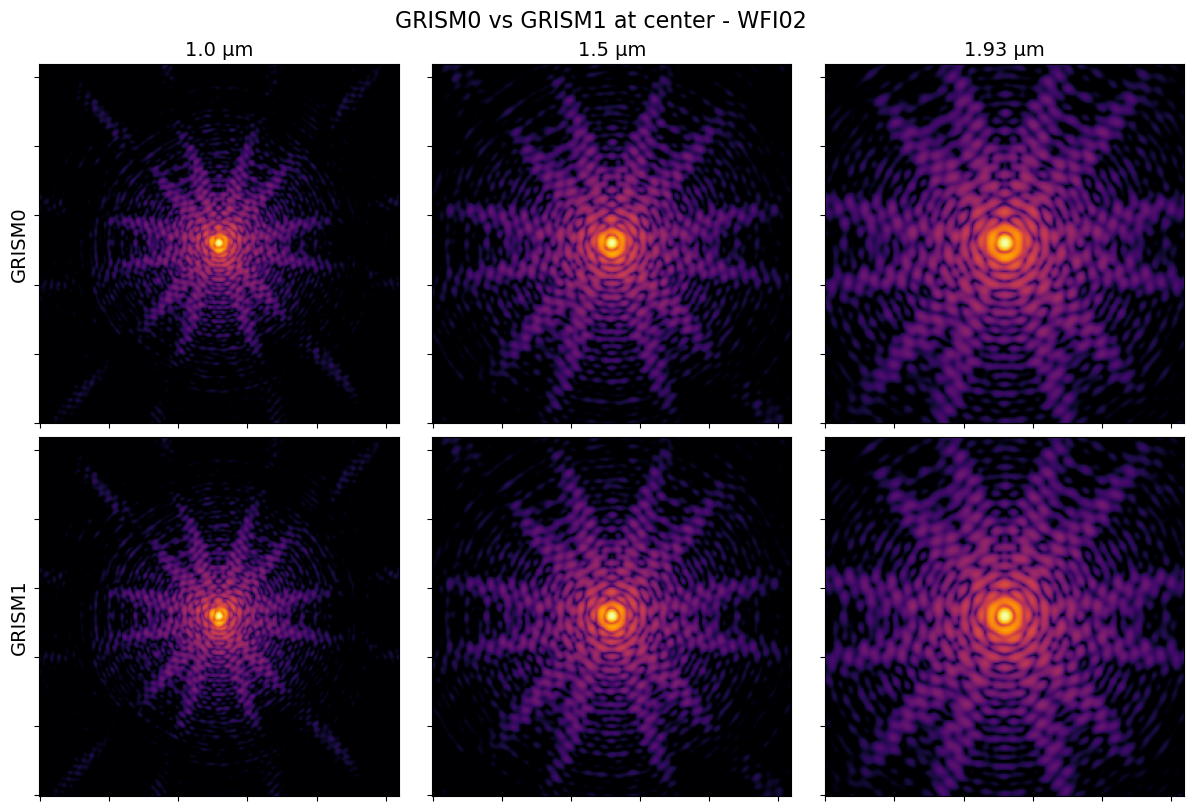

In [10]:
pos_name = 'center'

fig, axes = plt.subplots(
    len(ORDERS), len(WAVELENGTHS_UM), 
    figsize=(4 * len(WAVELENGTHS_UM), 4 * len(ORDERS)),
    constrained_layout=True
)

for i, order in enumerate(ORDERS):
    for j, wl_um in enumerate(WAVELENGTHS_UM):
        ax = axes[i, j]
        psf_array = psfs[order][pos_name][wl_um]
        
        vmax = psf_array.max()
        vmin = vmax * 1e-5
        
        im = ax.imshow(
            psf_array,
            origin='lower',
            cmap='inferno',
            norm=LogNorm(vmin=vmin, vmax=vmax)
        )
        
        if i == 0:
            ax.set_title(f'{wl_um} μm', fontsize=14)
        if j == 0:
            ax.set_ylabel(order, fontsize=14)
        
        ax.tick_params(labelbottom=False, labelleft=False)

fig.suptitle(f'GRISM0 vs GRISM1 at {pos_name} - {DETECTOR_PART1}', fontsize=16)
plt.show()

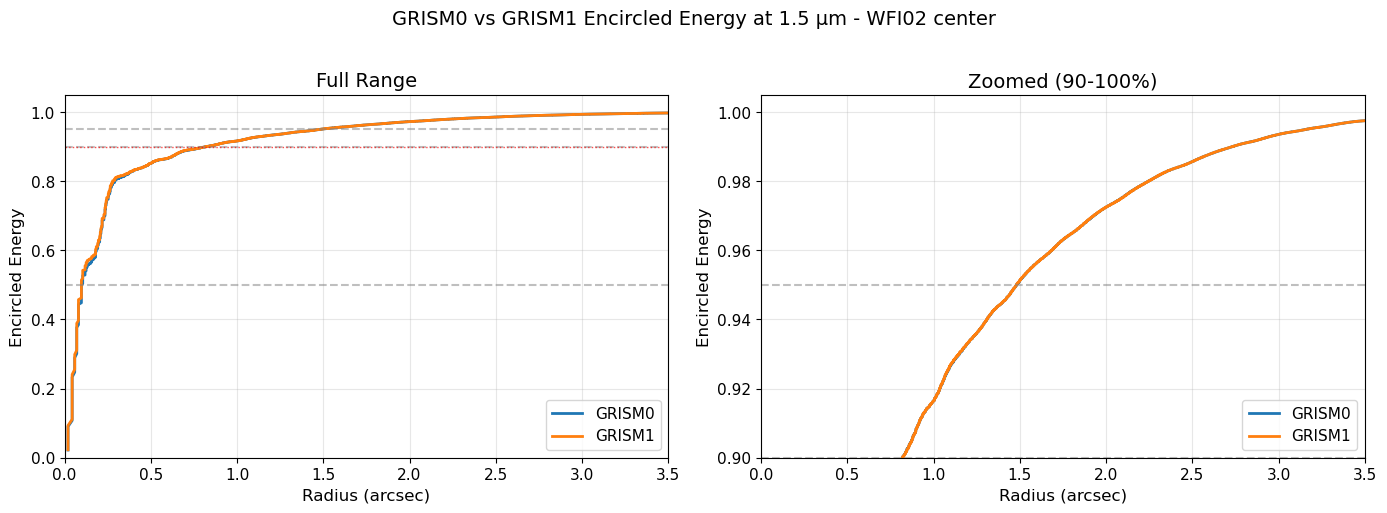

In [11]:
# EE comparison between GRISM0 and GRISM1
pos_name = 'center'
wl_um = 1.5

# Max radius is FOV/2
max_radius = FOV_ARCSEC / 2.0

fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(14, 5))

colors = {'GRISM0': 'tab:blue', 'GRISM1': 'tab:orange'}

for order in ORDERS:
    psf_array = psfs[order][pos_name][wl_um]
    radii, ee = compute_encircled_energy(psf_array, psf_pixel_scale)
    
    ax_full.plot(radii, ee, '-', color=colors[order], linewidth=2, label=order)
    ax_zoom.plot(radii, ee, '-', color=colors[order], linewidth=2, label=order)

# Full range plot (left)
for level in ee_levels:
    ax_full.axhline(level, color='gray', linestyle='--', alpha=0.5)
ax_full.axhline(0.90, color='red', linestyle=':', alpha=0.7, linewidth=1)
ax_full.set_xlabel('Radius (arcsec)', fontsize=12)
ax_full.set_ylabel('Encircled Energy', fontsize=12)
ax_full.set_title('Full Range', fontsize=14)
ax_full.set_xlim(0, max_radius)
ax_full.set_ylim(0, 1.05)
ax_full.legend(loc='lower right', fontsize=11)
ax_full.grid(alpha=0.3)

# Zoomed plot (right)
for level in [0.90, 0.95]:
    ax_zoom.axhline(level, color='gray', linestyle='--', alpha=0.5)
ax_zoom.set_xlabel('Radius (arcsec)', fontsize=12)
ax_zoom.set_ylabel('Encircled Energy', fontsize=12)
ax_zoom.set_title('Zoomed (90-100%)', fontsize=14)
ax_zoom.set_xlim(0, max_radius)
ax_zoom.set_ylim(0.90, 1.005)
ax_zoom.legend(loc='lower right', fontsize=11)
ax_zoom.grid(alpha=0.3)

fig.suptitle(f'GRISM0 vs GRISM1 Encircled Energy at {wl_um} μm - {DETECTOR_PART1} {pos_name}',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

# Part 2: All Detectors Survey (WFI01-WFI18)

Analyze PSFs at the center of all 18 WFI detectors at 1.5 μm.

In [12]:
# Configuration for Part 2
ALL_DETECTORS = [f'WFI{i:02d}' for i in range(1, 19)]
SURVEY_WAVELENGTH_UM = 1.5
SURVEY_WAVELENGTH_M = SURVEY_WAVELENGTH_UM * 1e-6
SURVEY_ORDER = 'GRISM1'
SURVEY_POSITION = (2044, 2044)  # Center

print(f"Survey Configuration:")
print(f"  Detectors: {len(ALL_DETECTORS)} (WFI01-WFI18)")
print(f"  Wavelength: {SURVEY_WAVELENGTH_UM} μm")
print(f"  Order: {SURVEY_ORDER}")
print(f"  Position: {SURVEY_POSITION} (center)")

Survey Configuration:
  Detectors: 18 (WFI01-WFI18)
  Wavelength: 1.5 μm
  Order: GRISM1
  Position: (2044, 2044) (center)


## PSF Calculation for All Detectors

In [13]:
# Calculate PSFs for all detectors
wfi = stpsf.roman.WFI()
wfi.filter = SURVEY_ORDER

x_stpsf, y_stpsf = sca_to_stpsf_position(
    float(SURVEY_POSITION[0]), float(SURVEY_POSITION[1])
)
wfi.detector_position = (float(x_stpsf), float(y_stpsf))

# Storage
detector_psfs = {}
detector_metrics = []

print(f"Calculating PSFs for {len(ALL_DETECTORS)} detectors...\n")
t_start = time.time()

for i, detector in enumerate(ALL_DETECTORS):
    wfi.detector = detector
    
    t0 = time.time()
    psf_array = calculate_psf(
        wfi, SURVEY_WAVELENGTH_M, FOV_ARCSEC, OVERSAMPLE, PSF_EXTENSION
    )
    elapsed = time.time() - t0
    
    detector_psfs[detector] = psf_array
    
    # Compute metrics
    radii, ee = compute_encircled_energy(psf_array, psf_pixel_scale)
    ee50 = find_ee_radius(radii, ee, 0.50)
    ee90 = find_ee_radius(radii, ee, 0.90)
    fwhm = estimate_fwhm_from_ee50(ee50)
    total_flux = psf_array.sum()
    
    detector_metrics.append({
        'Detector': detector,
        'Total Flux': total_flux,
        'FWHM est (arcsec)': fwhm,
        'EE50 (arcsec)': ee50,
        'EE90 (arcsec)': ee90,
    })
    
    print(f"  [{i+1}/{len(ALL_DETECTORS)}] {detector}: {elapsed:.2f}s, "
          f"FWHM≈{fwhm:.3f}\", EE50={ee50:.3f}\", EE90={ee90:.3f}\"")

t_total = time.time() - t_start
print(f"\nCompleted in {t_total:.1f} seconds ({t_total/len(ALL_DETECTORS):.2f}s per detector)")

Calculating PSFs for 18 detectors...

  [1/18] WFI01: 0.36s, FWHM≈0.194", EE50=0.097", EE90=0.856"
  [2/18] WFI02: 0.37s, FWHM≈0.194", EE50=0.097", EE90=0.820"
  [3/18] WFI03: 0.37s, FWHM≈0.209", EE50=0.105", EE90=0.866"
  [4/18] WFI04: 0.37s, FWHM≈0.194", EE50=0.097", EE90=0.840"
  [5/18] WFI05: 0.37s, FWHM≈0.194", EE50=0.097", EE90=0.856"
  [6/18] WFI06: 0.39s, FWHM≈0.209", EE50=0.105", EE90=0.867"
  [7/18] WFI07: 0.38s, FWHM≈0.209", EE50=0.105", EE90=0.883"
  [8/18] WFI08: 0.36s, FWHM≈0.209", EE50=0.105", EE90=0.872"
  [9/18] WFI09: 0.38s, FWHM≈0.261", EE50=0.130", EE90=0.887"
  [10/18] WFI10: 0.38s, FWHM≈0.194", EE50=0.097", EE90=0.858"
  [11/18] WFI11: 0.37s, FWHM≈0.194", EE50=0.097", EE90=0.820"
  [12/18] WFI12: 0.36s, FWHM≈0.194", EE50=0.097", EE90=0.839"
  [13/18] WFI13: 0.37s, FWHM≈0.209", EE50=0.105", EE90=0.871"
  [14/18] WFI14: 0.37s, FWHM≈0.209", EE50=0.105", EE90=0.858"
  [15/18] WFI15: 0.38s, FWHM≈0.194", EE50=0.097", EE90=0.871"
  [16/18] WFI16: 0.37s, FWHM≈0.209", EE50

## PSF Gallery - All Detectors

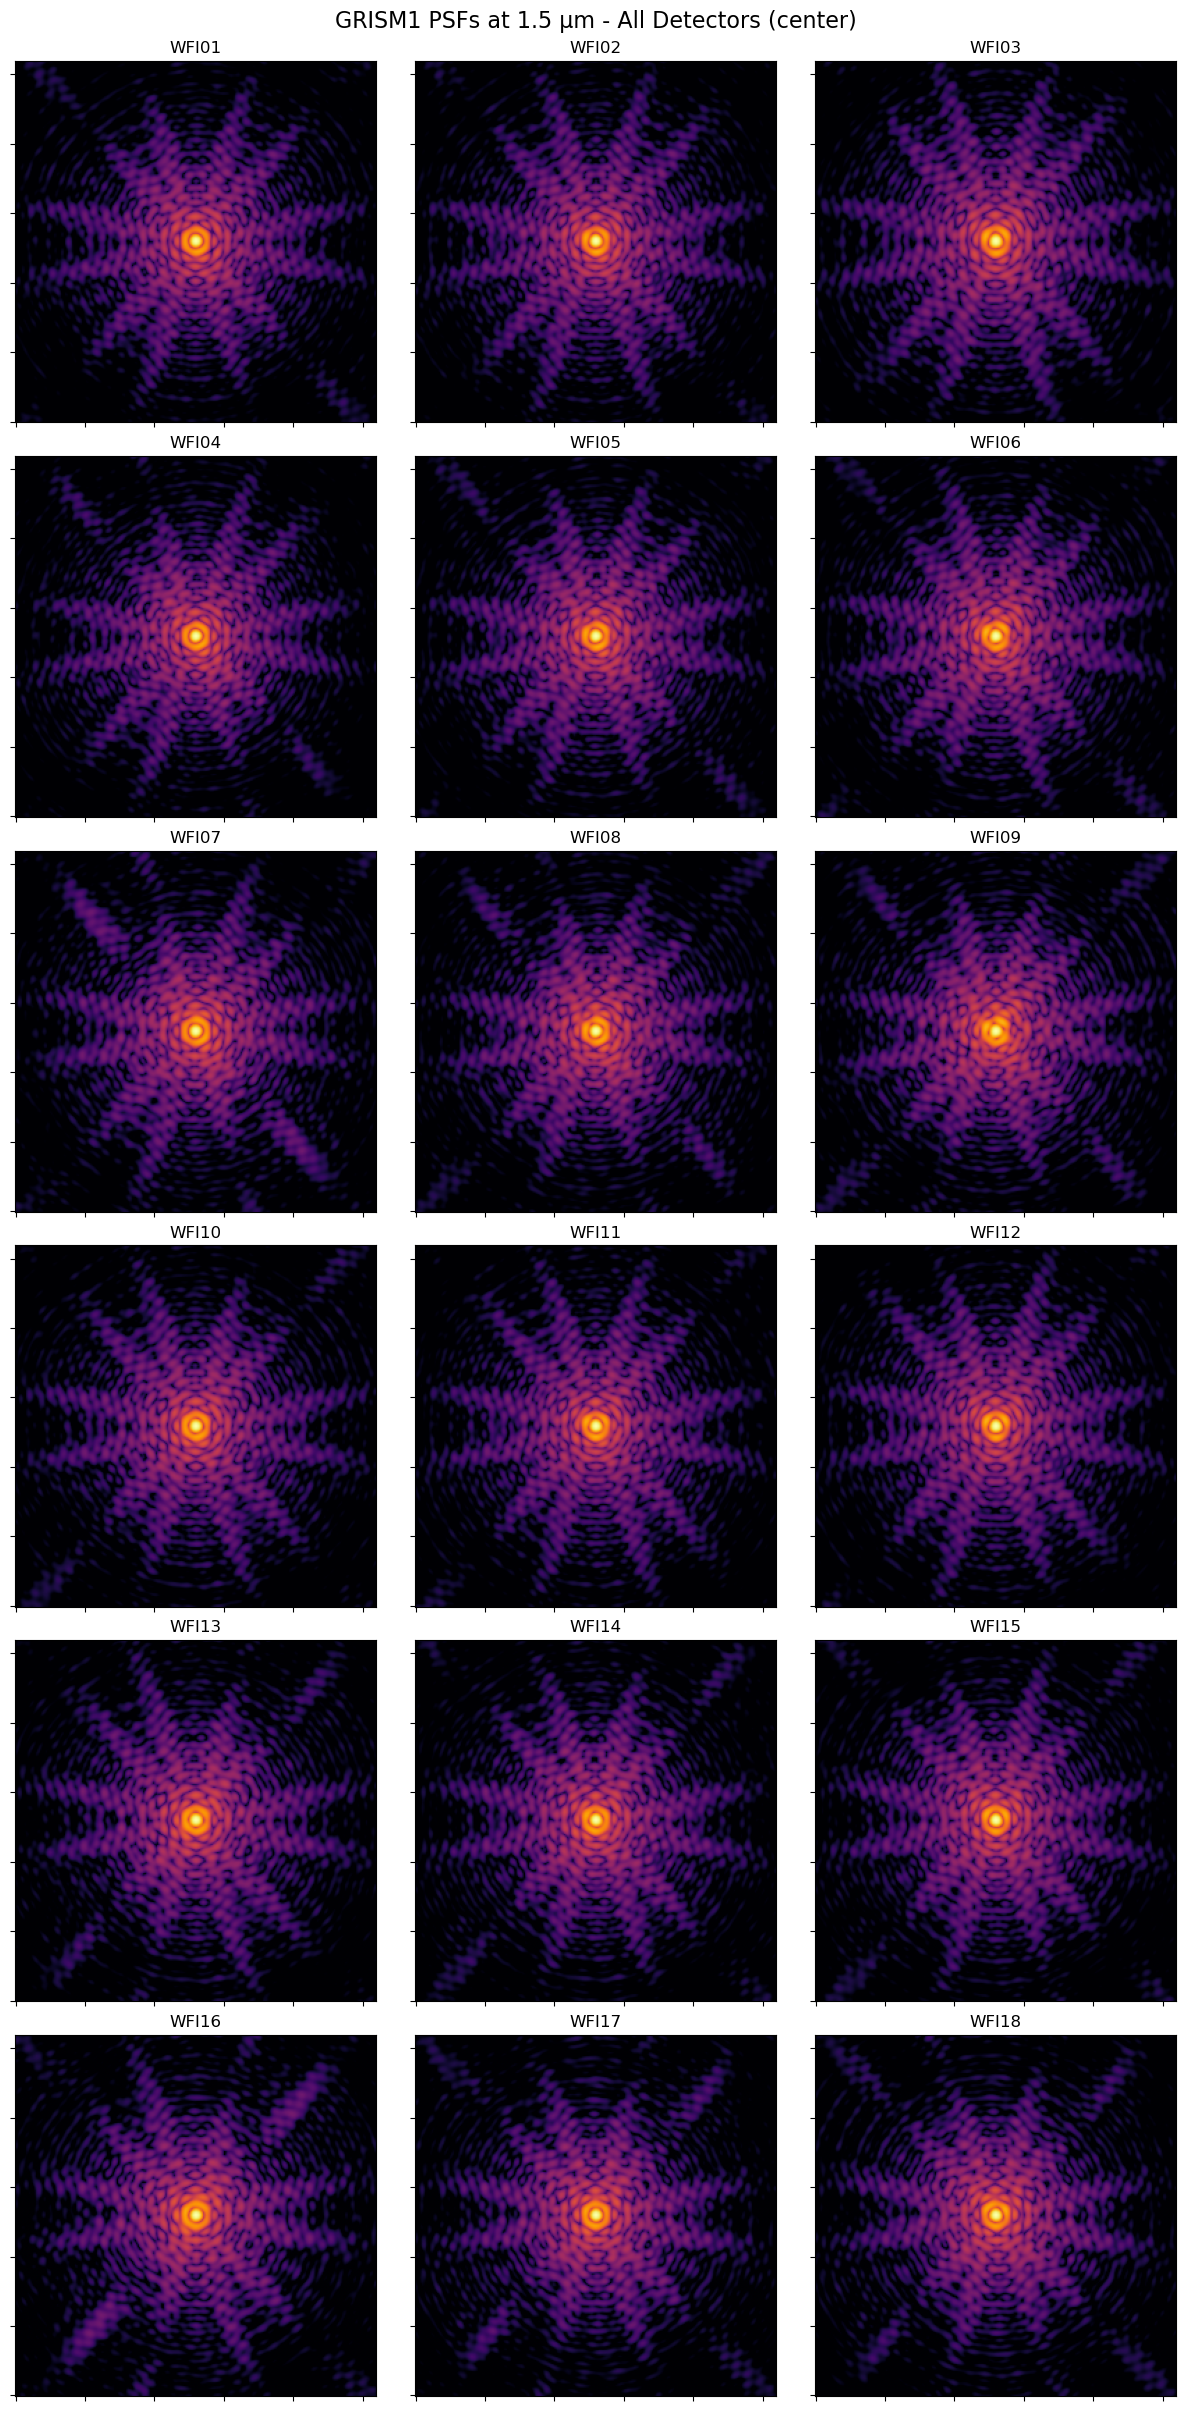

In [14]:
# 6×3 grid of all detector PSFs
n_rows, n_cols = 6, 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 24), constrained_layout=True)

for i, detector in enumerate(ALL_DETECTORS):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]
    
    psf_array = detector_psfs[detector]
    
    vmax = psf_array.max()
    vmin = vmax * 1e-5
    
    im = ax.imshow(
        psf_array,
        origin='lower',
        cmap='inferno',
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    
    ax.set_title(detector, fontsize=12)
    ax.tick_params(labelbottom=False, labelleft=False)

fig.suptitle(f'{SURVEY_ORDER} PSFs at {SURVEY_WAVELENGTH_UM} μm - All Detectors (center)',
             fontsize=16)
plt.show()

## Summary Table - All Detectors

In [15]:
# Create summary table
metrics_df = pd.DataFrame(detector_metrics)

# Format numeric columns
metrics_df['Total Flux'] = metrics_df['Total Flux'].apply(lambda x: f'{x:.4f}')
metrics_df['FWHM est (arcsec)'] = metrics_df['FWHM est (arcsec)'].apply(lambda x: f'{x:.3f}')
metrics_df['EE50 (arcsec)'] = metrics_df['EE50 (arcsec)'].apply(lambda x: f'{x:.3f}')
metrics_df['EE90 (arcsec)'] = metrics_df['EE90 (arcsec)'].apply(lambda x: f'{x:.3f}')

print(f"\n{SURVEY_ORDER} PSF Metrics at {SURVEY_WAVELENGTH_UM} μm - All Detectors (center)")
print("Note: FWHM ≈ 2 × EE50 radius")
print("=" * 70)
metrics_df


GRISM1 PSF Metrics at 1.5 μm - All Detectors (center)
Note: FWHM ≈ 2 × EE50 radius


,Detector,Total Flux,FWHM est (arcsec),EE50 (arcsec),EE90 (arcsec)
0,WFI01,0.9778,0.194,0.097,0.856
1,WFI02,0.9782,0.194,0.097,0.820
2,WFI03,0.9776,0.209,0.105,0.866
3,WFI04,0.9776,0.194,0.097,0.840
4,WFI05,0.9777,0.194,0.097,0.856
5,WFI06,0.9774,0.209,0.105,0.867
6,WFI07,0.9752,0.209,0.105,0.883
7,WFI08,0.9766,0.209,0.105,0.872
8,WFI09,0.9771,0.261,0.130,0.887
9,WFI10,0.9777,0.194,0.097,0.858


## Metrics Visualization

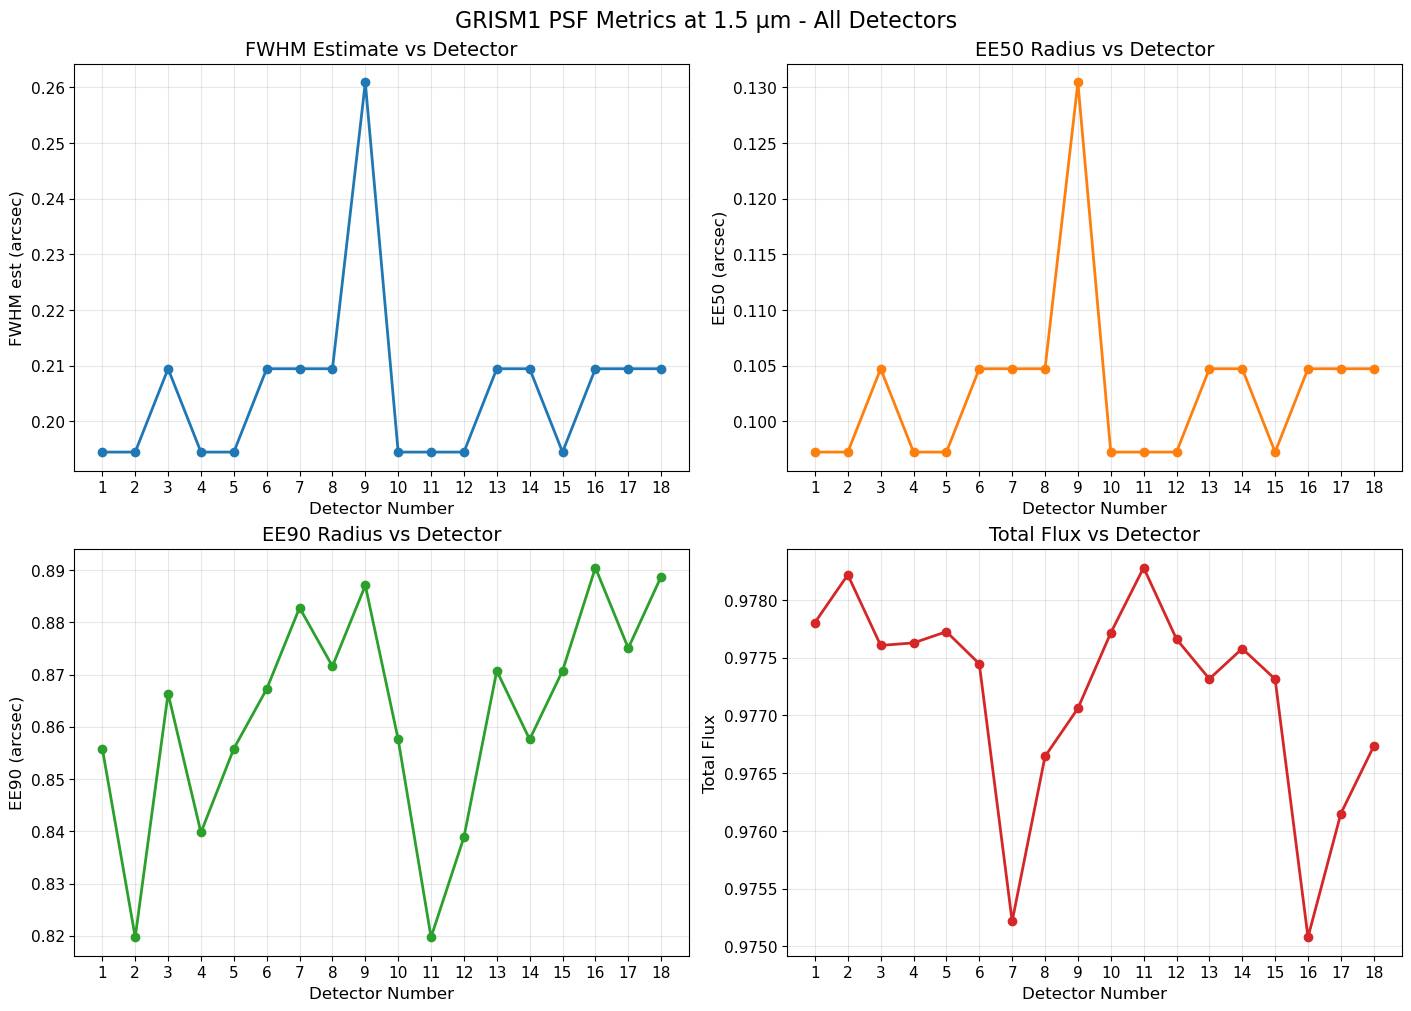

In [16]:
# Recreate metrics with numeric values for plotting
metrics_numeric = pd.DataFrame(detector_metrics)

# Extract detector numbers for x-axis
detector_nums = [int(d[3:]) for d in metrics_numeric['Detector']]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

# FWHM estimate
ax = axes[0, 0]
ax.plot(detector_nums, metrics_numeric['FWHM est (arcsec)'], 'o-', color='tab:blue', linewidth=2)
ax.set_xlabel('Detector Number', fontsize=12)
ax.set_ylabel('FWHM est (arcsec)', fontsize=12)
ax.set_title('FWHM Estimate vs Detector', fontsize=14)
ax.set_xticks(detector_nums)
ax.grid(alpha=0.3)

# EE50
ax = axes[0, 1]
ax.plot(detector_nums, metrics_numeric['EE50 (arcsec)'], 'o-', color='tab:orange', linewidth=2)
ax.set_xlabel('Detector Number', fontsize=12)
ax.set_ylabel('EE50 (arcsec)', fontsize=12)
ax.set_title('EE50 Radius vs Detector', fontsize=14)
ax.set_xticks(detector_nums)
ax.grid(alpha=0.3)

# EE90
ax = axes[1, 0]
ax.plot(detector_nums, metrics_numeric['EE90 (arcsec)'], 'o-', color='tab:green', linewidth=2)
ax.set_xlabel('Detector Number', fontsize=12)
ax.set_ylabel('EE90 (arcsec)', fontsize=12)
ax.set_title('EE90 Radius vs Detector', fontsize=14)
ax.set_xticks(detector_nums)
ax.grid(alpha=0.3)

# Total Flux
ax = axes[1, 1]
ax.plot(detector_nums, metrics_numeric['Total Flux'], 'o-', color='tab:red', linewidth=2)
ax.set_xlabel('Detector Number', fontsize=12)
ax.set_ylabel('Total Flux', fontsize=12)
ax.set_title('Total Flux vs Detector', fontsize=14)
ax.set_xticks(detector_nums)
ax.grid(alpha=0.3)

fig.suptitle(f'{SURVEY_ORDER} PSF Metrics at {SURVEY_WAVELENGTH_UM} μm - All Detectors',
             fontsize=16)
plt.show()

## Summary

This notebook has analyzed the PSF characteristics of the Roman Space Telescope grism:

**Part 1 Findings:**
- PSF shape varies with detector position (center vs corners)
- PSF broadens at longer wavelengths (diffraction-limited behavior)
- GRISM0 (undispersed) and GRISM1 (dispersed) show similar PSF structure

**Part 2 Findings:**
- PSF metrics vary across the 18 WFI detectors
- Total flux should be near 1.0 (normalized PSF)
- Field-dependent variations are important for accurate spectral extraction

**Next Steps:**
- Generate PSF payloads for disperser integration using `psf_model.make_psf_payload()`
- Use wavelength-dependent PSFs for accurate star dispersion